In [1]:
import torch
import torch.nn as nn
import numpy as np
import time
import math
from matplotlib import pyplot
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import math

torch.manual_seed(0)
np.random.seed(0)
input_window = 19
output_window = 1
batch_size = 1
start_lr = 0.00001
scheduler_gamma = 0.87
epochs = 10

from sklearn.preprocessing import StandardScaler, RobustScaler
#scaler = StandardScaler()
scaler = RobustScaler()

data_folder = "run475"
data_file = "A2.csv"
target = "DOT"

feature_size = 1
# The flag decides if the loss will be calculted over all
# or just the predicted values.
calculate_loss_over_all_values = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("data_folder: " + data_folder)
print("data_file: " + data_file)
print("target: " + target)
print("input_window: " + str(input_window))
print("output_window: " + str(output_window))
print("batch_size: " + str(batch_size))
print("start_lr: " + str(start_lr))
print("epochs: " + str(epochs))
print("feature_size: " + str(feature_size))

#print("Loss: " + loss)
print("Loss RMSE")
print("===================================")

data_folder: run475
data_file: A2.csv
target: DOT
input_window: 19
output_window: 1
batch_size: 1
start_lr: 1e-05
epochs: 10
feature_size: 1
Loss RMSE


In [2]:
class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self,yhat,y):
        return torch.sqrt(self.mse(yhat,y))

criterion = RMSELoss()

In [3]:
data = pd.read_pickle('kiwi_experiments_and_run_355.pk')

In [4]:
runs = data.keys() 
run_id = 482
print(runs)

dict_keys([355, 439, 445, 449, 468, 474, 475, 482, 484])


In [5]:
experiments = data[482].keys()
experiment_id_1 = 16282
experiment_id_2 = 16283
experiment_id_3 = 16284
print(experiments)

dict_keys([16282, 16283, 16284, 16285, 16286, 16287, 16288, 16289, 16290, 16291, 16292, 16293, 16294, 16295, 16296, 16297, 16298, 16299, 16300, 16301, 16302, 16303, 16304, 16305])


In [6]:
metadata = data[run_id][experiment_id_1]["metadata"]
setpoints = data[run_id][experiment_id_1]["setpoints"]
measurements_reactor = data[run_id][experiment_id_1]["measurements_reactor"]
measurements_array = data[run_id][experiment_id_1]["measurements_array"]
measurements_aggregated = data[run_id][experiment_id_1]["measurements_aggregated"]
#print(data[run_id][experiment_id].keys())

In [7]:
print(data[run_id][experiment_id_1]["metadata"])

   experiment_id  bioreactor_id  container_number  profile_id  \
0          16282            586                 9     10961.0   

  starter_culture_id  inactivation_method_id description_x      color  \
0               None                     1.0          None  #FF1B9E77   

  profile_name  folder_id_x  ...           run_name  folder_id_y  pms_id  \
0           A2          NaN  ...  20210630_MPC_exp5          101       2   

  status_id          start_time            end_time description conclusion  \
0         3 2021-06-30 09:37:36 2021-06-30 15:02:30        None       None   

  container_label is_template  
0            None           0  

[1 rows x 34 columns]


In [8]:
df_metadata = pd.DataFrame(data=metadata)
df_metadata

,experiment_id,bioreactor_id,container_number,profile_id,starter_culture_id,inactivation_method_id,description_x,color,profile_name,folder_id_x,...,run_name,folder_id_y,pms_id,status_id,start_time,end_time,description,conclusion,container_label,is_template
0,16282,586,9,10961.0,None,1.0,None,#FF1B9E77,A2,NaN,...,20210630_MPC_exp5,101,2,3,2021-06-30 09:37:36,2021-06-30 15:02:30,None,None,None,0


In [9]:
df_setpoints = pd.DataFrame(data=setpoints)
df_setpoints

,cultivation_age,setpoint_id,unit,Feed_glc_cum_setpoints,Flow_Air,Puls_AceticAcid,Puls_Glucose,Puls_Medium,StirringSpeed,pH
0,0,727619,-,NaN,NaN,NaN,NaN,NaN,NaN,7.0
1,0,727620,µL,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,0,727621,µL,NaN,NaN,0.0,NaN,NaN,NaN,NaN
3,0,727622,µL,NaN,NaN,NaN,NaN,0.0,NaN,NaN
5,0,727625,U/min,NaN,NaN,NaN,NaN,NaN,2400.0,NaN
4,1,727623,U/min,NaN,NaN,NaN,NaN,NaN,2400.0,NaN
6,1,727624,Ln/min,NaN,5.0,NaN,NaN,NaN,NaN,NaN
7,12694,727975,µL,3.0,NaN,NaN,NaN,NaN,NaN,NaN
8,13294,727976,µL,7.0,NaN,NaN,NaN,NaN,NaN,NaN
9,13894,727977,µL,10.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_setpoints.describe()

,cultivation_age,setpoint_id,Feed_glc_cum_setpoints,Flow_Air,Puls_AceticAcid,Puls_Glucose,Puls_Medium,StirringSpeed,pH
count,37.000000,37.000000,30.000000,1.0,1.0,1.0,1.0,2.0,1.0
mean,17346.540541,727919.972973,59.900000,5.0,0.0,0.0,0.0,2400.0,7.0
std,9727.974751,146.136444,37.331091,NaN,NaN,NaN,NaN,0.0,NaN
min,0.000000,727619.000000,3.000000,5.0,0.0,0.0,0.0,2400.0,7.0
25%,13894.000000,727977.000000,28.750000,5.0,0.0,0.0,0.0,2400.0,7.0
50%,19294.000000,727986.000000,57.000000,5.0,0.0,0.0,0.0,2400.0,7.0
75%,24694.000000,727995.000000,89.750000,5.0,0.0,0.0,0.0,2400.0,7.0
max,30094.000000,728004.000000,126.000000,5.0,0.0,0.0,0.0,2400.0,7.0


In [11]:
df_measurements_reactor = pd.DataFrame(data=measurements_reactor)
df_measurements_reactor

,measurement_time,measurement_id,unit,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Fluo_GFP,OD600,Probe_Volume,Volume,pH
0,2021-06-30 09:39:06,22771715,-,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
640,2021-06-30 09:39:06,22771716,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.61
1,2021-06-30 09:39:16,22771763,-,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
641,2021-06-30 09:39:16,22771764,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.61
2,2021-06-30 09:39:31,22771811,-,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1277,2021-06-30 15:06:43,22803877,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.02
1278,2021-06-30 15:06:54,22803925,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.02
638,2021-06-30 15:06:54,22803924,-,NaN,NaN,NaN,96.61,NaN,NaN,NaN,NaN,NaN
639,2021-06-30 15:07:08,22803972,-,NaN,NaN,NaN,96.72,NaN,NaN,NaN,NaN,NaN


In [12]:
df_measurements_reactor.describe()

,measurement_id,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Fluo_GFP,OD600,Probe_Volume,Volume,pH
count,1.340000e+03,10.000000,11.000000,2.000000,640.000000,4.000000,4.000000,6.000000,23.000000,640.000000
mean,2.278780e+07,43.400000,20.636364,26.709549,88.711391,1892.500000,12.782500,700.000000,91.601027,6.982859
std,9.322083e+03,20.034415,11.826011,4.056583,11.527553,2389.721044,21.022994,374.165739,39.552572,0.093725
min,2.277172e+07,10.000000,3.000000,23.841111,0.000000,437.500000,0.212500,200.000000,10.000000,6.610000
25%,2.277972e+07,31.500000,11.500000,25.275330,85.127500,587.500000,0.362500,450.000000,67.841111,6.930000
50%,2.278782e+07,44.000000,20.000000,26.709549,91.745000,837.500000,3.452500,700.000000,103.577986,6.980000
75%,2.279587e+07,57.500000,29.500000,28.143767,94.787500,2142.500000,15.872500,950.000000,122.077986,7.060000
max,2.280397e+07,74.000000,39.000000,29.577986,97.140000,5457.500000,44.012500,1200.000000,142.577986,7.130000


In [13]:
df_measurements_array = pd.DataFrame(data=measurements_array)
df_measurements_array

,measurement_time,measurement_id,unit,Flow_Air,Flow_Nitrogen,Flow_O2,StirringSpeed,Temperature
0,2021-06-30 09:39:06,1408746,°C,NaN,NaN,NaN,NaN,37.82
476,2021-06-30 09:39:48,1408747,U/min,NaN,NaN,NaN,0.0,NaN
1,2021-06-30 09:39:48,1408748,°C,NaN,NaN,NaN,NaN,36.72
477,2021-06-30 09:40:13,1408749,U/min,NaN,NaN,NaN,0.0,NaN
2,2021-06-30 09:40:14,1408750,°C,NaN,NaN,NaN,NaN,36.48
...,...,...,...,...,...,...,...,...
482,2021-06-30 15:06:58,1409225,Ln/min,NaN,0.0,NaN,NaN,NaN
481,2021-06-30 15:07:14,1409229,Ln/min,0.0,NaN,NaN,NaN,NaN
483,2021-06-30 15:07:14,1409228,Ln/min,NaN,0.0,NaN,NaN,NaN
485,2021-06-30 15:07:14,1409230,Ln/min,NaN,NaN,0.0,NaN,NaN


In [14]:
print(df_measurements_array.describe())

       measurement_id  Flow_Air  Flow_Nitrogen  Flow_O2  StirringSpeed  \
count    4.860000e+02  3.000000            2.0      2.0            3.0   
mean     1.408988e+06  1.666667            0.0      0.0            0.0   
std      1.404404e+02  2.886751            0.0      0.0            0.0   
min      1.408746e+06  0.000000            0.0      0.0            0.0   
25%      1.408867e+06  0.000000            0.0      0.0            0.0   
50%      1.408988e+06  0.000000            0.0      0.0            0.0   
75%      1.409110e+06  2.500000            0.0      0.0            0.0   
max      1.409231e+06  5.000000            0.0      0.0            0.0   

       Temperature  
count   476.000000  
mean     37.469706  
std       0.382081  
min      34.380000  
25%      37.460000  
50%      37.510000  
75%      37.570000  
max      37.910000  


In [15]:
df_measurements_array.isnull().sum()

measurement_time      0
measurement_id        0
unit                  0
Flow_Air            483
Flow_Nitrogen       484
Flow_O2             484
StirringSpeed       483
Temperature          10
dtype: int64

In [16]:
df_measurements_array.size

3888

In [17]:
df_measurements_aggregated = pd.DataFrame(data=measurements_aggregated)
df_measurements_aggregated

,measurement_time,unit,Flow_Air,Flow_Nitrogen,Flow_O2,StirringSpeed,Temperature,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Fluo_GFP,OD600,Probe_Volume,Volume,pH
0,2021-06-30 09:39:06,°C,NaN,NaN,NaN,NaN,37.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-06-30 09:39:06,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.61
2,2021-06-30 09:39:06,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
3,2021-06-30 09:39:16,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN
4,2021-06-30 09:39:16,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,2021-06-30 15:07:08,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.72,NaN,NaN,NaN,NaN,NaN
1822,2021-06-30 15:07:14,Ln/min,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1823,2021-06-30 15:07:14,Ln/min,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1824,2021-06-30 15:07:14,Ln/min,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
print(df_measurements_aggregated.describe())

       Flow_Air  Flow_Nitrogen  Flow_O2  StirringSpeed  Temperature  \
count  3.000000            2.0      2.0            3.0   476.000000   
mean   1.666667            0.0      0.0            0.0    37.469706   
std    2.886751            0.0      0.0            0.0     0.382081   
min    0.000000            0.0      0.0            0.0    34.380000   
25%    0.000000            0.0      0.0            0.0    37.460000   
50%    0.000000            0.0      0.0            0.0    37.510000   
75%    2.500000            0.0      0.0            0.0    37.570000   
max    5.000000            0.0      0.0            0.0    37.910000   

            Base  Cumulated_feed_volume_glucose  Cumulated_feed_volume_medium  \
count  10.000000                      11.000000                      2.000000   
mean   43.400000                      20.636364                     26.709549   
std    20.034415                      11.826011                      4.056583   
min    10.000000                    

In [19]:
print(df_measurements_aggregated.size)
print(df_measurements_aggregated.isnull().sum())

29216
measurement_time                    0
unit                                0
Flow_Air                         1823
Flow_Nitrogen                    1824
Flow_O2                          1824
StirringSpeed                    1823
Temperature                      1350
Base                             1816
Cumulated_feed_volume_glucose    1815
Cumulated_feed_volume_medium     1824
DOT                              1186
Fluo_GFP                         1822
OD600                            1822
Probe_Volume                     1820
Volume                           1803
pH                               1186
dtype: int64


In [20]:
#plt.figure(figsize=(12,8))
#plt.grid(True, which='both')
#plt.plot(df_measurements_aggregated['DOT'])
#plt.show()

In [21]:
#%matplotlib inline
#plt.figure(figsize=(24,4))
#plt.grid(True)
#plt.style.use('seaborn-whitegrid')
#plt.ylim([80,100])
#plt.plot(df_measurements_aggregated['DOT'], 'ob')
#plt.style.use('default')
#plt.title("DOT")
#plt.show()

In [22]:
fill_DOT = df_measurements_aggregated['DOT'].fillna(method='ffill').fillna(method='bfill')

In [23]:
train_set = data[run_id][experiment_id_1]["measurements_aggregated"][target]
valid_set = data[run_id][experiment_id_2]["measurements_aggregated"][target]
test_set = data[run_id][experiment_id_3]["measurements_aggregated"][target]

train_control = data[run_id][experiment_id_1]["measurements_aggregated"]['Cumulated_feed_volume_glucose']
valid_control = data[run_id][experiment_id_2]["measurements_aggregated"]['Cumulated_feed_volume_glucose']
test_control = data[run_id][experiment_id_3]["measurements_aggregated"]['Cumulated_feed_volume_glucose']

In [24]:
#print(train_set)
#print(valid_set)
#print(test_set)

In [25]:
train_set_fill = data[run_id][experiment_id_1]["measurements_aggregated"][target].fillna(method='ffill').fillna(method='bfill')
valid_set_fill = data[run_id][experiment_id_2]["measurements_aggregated"][target].fillna(method='ffill').fillna(method='bfill')
test_set_fill = data[run_id][experiment_id_3]["measurements_aggregated"][target].fillna(method='ffill').fillna(method='bfill')

In [26]:
#%matplotlib inline
#plt.figure(figsize=(20,4))
#plt.grid(True)
#plt.plot(test_set_fill, marker="o", markersize=4, color='g')
#plt.style.use('default')
#plt.title("DOT")
#plt.show()

In [27]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(1000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        #pe.requires_grad = False
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class Transformer_TS(nn.Module):
    def __init__(self, nhidden=1024, num_layers=1, nhead=8, dropout=0.1, in_channels=input_window,
                 out_channels=output_window):
        super(Transformer_TS, self).__init__()
        self.model_type = 'Transformer for TS'

        self.src_mask = None
        self.pos_encoder = PositionalEncoding(nhidden)

        self.encoder_layer = nn.TransformerEncoderLayer(d_model=nhidden, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(nhidden, 1)  # nn.Linear(nhidden,1)
        self.init_weights()

        self.conv1 = self.contract_block(in_channels, 48, 3, 1)
        self.conv2 = self.contract_block(48, 96, 3, 1)
        self.conv3 = self.contract_block(96, 192, 3, 1)
        self.conv4 = self.contract_block(192, 384, 3, 1)

        self.upconv4 = self.expand_block(384, 192, 3, 1)
        self.upconv3 = self.expand_block(192 * 2, 96, 3, 1)
        self.upconv2 = self.expand_block(96 * 2, 48, 3, 1)
        self.upconv1 = self.expand_block(48 * 2, out_channels, 3, 1)

    def init_weights(self):
        initrange = 0.1
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        if self.src_mask is None or self.src_mask.size(0) != len(src):
            device = src.device
            mask = self._generate_square_subsequent_mask(len(src)).to(device)
            self.src_mask = mask

        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, self.src_mask)

        # u-net block
        output = torch.reshape(output, (output.shape[1], output.shape[0], output.shape[2]))

        conv1 = self.conv1(output)
        conv2 = self.conv2(conv1)
        conv3 = self.conv3(conv2)
        conv4 = self.conv4(conv3)

        upconv4 = self.upconv4(conv4)
        upconv3 = self.upconv3(torch.cat([upconv4, conv3], 1))
        upconv2 = self.upconv2(torch.cat([upconv3, conv2], 1))
        upconv1 = self.upconv1(torch.cat([upconv2, conv1], 1))

        upconv1 = torch.reshape(upconv1, (upconv1.shape[1], upconv1.shape[0], upconv1.shape[2]))
        # u-net block

        output = self.decoder(upconv1)
        return output

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def contract_block(self, in_channels, out_channels, kernel_size, padding):
        contract = nn.Sequential(
            torch.nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            # torch.nn.BatchNorm1d(out_channels),
            # torch.nn.ReLU(),
            torch.nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            # torch.nn.BatchNorm1d(out_channels),
            # torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
            torch.nn.Dropout(p=0.1)
        )

        return contract

    def expand_block(self, in_channels, out_channels, kernel_size, padding):
        expand = nn.Sequential(
            torch.nn.Conv1d(in_channels, out_channels, kernel_size, stride=1, padding=padding),
            # torch.nn.BatchNorm1d(out_channels),
            # torch.nn.ReLU(),
            torch.nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=padding),
            # torch.nn.BatchNorm1d(out_channels),
            # torch.nn.ReLU(),
            torch.nn.ConvTranspose1d(out_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            torch.nn.Dropout(p=0.1)
        )
        return expand


In [28]:
def create_inout_sequences(input_data, input_window):
    inout_seq = []
    L = len(input_data)
    for i in range(L - input_window):
        train_seq = np.append(input_data[i:i + input_window][:-output_window], output_window * [0])
        train_label = input_data[i:i + input_window]
        # train_label = input_data[i+output_window:i+input_window+output_window]
        inout_seq.append((train_seq, train_label))
    return torch.FloatTensor(inout_seq)

In [29]:
def get_data(dataset=data_file, target=target):
    from pandas import read_csv
    
    train_data = train_set_fill
    valid_data = valid_set_fill
    test_data = test_set_fill
    
    train_data = scaler.fit_transform(train_data.to_numpy().reshape(-1, 1)).reshape(-1)
    valid_data = scaler.transform(valid_data.to_numpy().reshape(-1, 1)).reshape(-1)
    test_data = scaler.transform(test_data.to_numpy().reshape(-1, 1)).reshape(-1)
    
    train_sequence = create_inout_sequences(train_data, input_window)
    train_sequence = train_sequence[:-output_window]

    valid_sequence = create_inout_sequences(valid_data, input_window)
    valid_sequence = valid_sequence[:-output_window]

    test_sequence = create_inout_sequences(test_data, input_window)
    test_sequence = test_sequence[:-output_window]

    return train_sequence.to(device), valid_sequence.to(device), test_sequence.to(device)

In [30]:
def get_batch(source, i, batch_size, feature_size=feature_size):
    seq_len = min(batch_size, len(source) - 1 - i)
    data = source[i:i + seq_len]
    observation = torch.stack(
        torch.stack([item[0] for item in data]).chunk(input_window, feature_size))  # 1 is feature size
    target = torch.stack(torch.stack([item[1] for item in data]).chunk(input_window, feature_size))
    return observation, target

In [31]:
def train(train_data):
    model.train()  # Turn on the train mode
    total_loss = 0.
    start_time = time.time()

    for batch, i in enumerate(range(0, len(train_data) - 1, batch_size)):
        data, targets = get_batch(train_data, i, batch_size, feature_size)
        optimizer.zero_grad()
        output = model(data)

        if calculate_loss_over_all_values:
            loss = criterion(output, targets)
        else:
            loss = criterion(output[-output_window:], targets[-output_window:])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        total_loss += loss.item()
        log_interval = int(len(train_data) / batch_size / 2)  # / 5
        if batch % log_interval == 0 and batch > 0:
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print('| epoch {:3d}/{} | {:5d}/{:5d} batches | '
                  'lr {:02.10f} | {:6.2f} ms | '
                  'loss {:5.5f}'.format(
                epoch, epochs, batch, len(train_data) // batch_size, scheduler.get_last_lr()[0],
                                      elapsed * 1000 / log_interval,
                cur_loss))
            total_loss = 0
            start_time = time.time()

In [32]:
def evaluate(eval_model, data_source):
    eval_model.eval()
    total_loss = 0.
    eval_batch_size = 1
    outputs = []
    with torch.no_grad():
        for i in range(0, len(data_source) - 1, eval_batch_size):
            data, targets = get_batch(data_source, i,eval_batch_size, feature_size)
            output = eval_model(data)
            outputs.append(output)
            if calculate_loss_over_all_values:
                total_loss += len(data[0])* criterion(output, targets).cpu().item()
            else:
                total_loss += len(data[0])* criterion(output[-output_window:], targets[-output_window:]).cpu().item()
    return total_loss / len(data_source), outputs


In [33]:
train_data, val_data, test_data = get_data()

model = Transformer_TS().to(device)

lr = start_lr
lrs = []

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2.0, gamma=scheduler_gamma)
#scheduler1 = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
#scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

best_val_loss = float("inf")
future_horizon = output_window

/tmp/ipykernel_70290/593583881.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  /opt/conda/conda-bld/pytorch_1634272204863/work/torch/csrc/utils/tensor_new.cpp:201.)
  return torch.FloatTensor(inout_seq)


In [34]:
for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(train_data)

    if (epoch % 5 == 0):
        pass
        #val_loss = plot_and_loss(model, val_data, epoch)
        #predict_future(model, val_data, future_horizon)
    else:
        val_loss,_ = evaluate(model, val_data)

    print('-' * 100)

    print('| end of epoch {:3d}/{} | time: {:5.2f}s | valid loss {:5.5f}'.format(epoch, epochs,(time.time() - epoch_start_time),val_loss))
    print('-' * 100)
    scheduler.step()
    
print("evaluate test_data:")
rmse, predicted_test = evaluate(model, test_data)
print(rmse)

| epoch   1/10 |   903/ 1806 batches | lr 0.0000100000 |  10.34 ms | loss 0.15722
----------------------------------------------------------------------------------------------------
| end of epoch   1/10 | time: 21.76s | valid loss 0.83295
----------------------------------------------------------------------------------------------------
| epoch   2/10 |   903/ 1806 batches | lr 0.0000100000 |   9.91 ms | loss 0.14793
----------------------------------------------------------------------------------------------------
| end of epoch   2/10 | time: 21.83s | valid loss 0.74422
----------------------------------------------------------------------------------------------------
| epoch   3/10 |   903/ 1806 batches | lr 0.0000087000 |   9.84 ms | loss 0.14134
----------------------------------------------------------------------------------------------------
| end of epoch   3/10 | time: 21.31s | valid loss 0.69324
---------------------------------------------------------------------------

In [35]:
def convert_to_np_array(predicted_test):
    length = len(predicted_test)
    outputs = []
    for i in range(length):
        outputs.append(predicted_test[i][0][0][0].cpu().item())
    return np.array(outputs).reshape(-1, 1)

In [36]:
predicted_test = convert_to_np_array(predicted_test)

In [37]:
inversed = scaler.inverse_transform(predicted_test)

In [38]:
#print(inversed)
print(len(inversed))
print(len(predicted_test))

1801
1801


FileNotFoundError: [Errno 2] No such file or directory: 'graph/run_id_482,exp_id_16284,target_DOT.png'

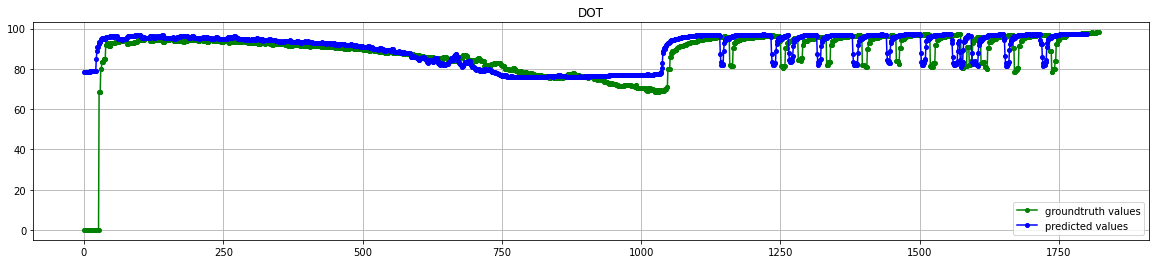

In [39]:
plt.figure(figsize=(20,4))
plt.grid(True)
plt.style.use('default')
plt.title(target)
plt.plot(test_set_fill, marker="o", markersize=4, color='g', label="groundtruth values")
plt.plot(inversed, marker="o", markersize=4, color='b', label="predicted values")
plt.legend(loc='best')
plt.savefig('graph/run_id_{},exp_id_{},target_{}.png'.format(run_id, experiment_id_3, target))
plt.show()